## importing basic libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Extraction

In [25]:
import kagglehub
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [26]:
df = pd.read_csv("/kaggle/input/red-wine-quality-cortez-et-al-2009/winequality-red.csv")

In [27]:
df.sample(6)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
699,11.8,0.38,0.55,2.1,0.071,5.0,19.0,0.99860,3.11,0.62,10.80,6
1330,7.4,0.60,0.26,2.1,0.083,17.0,91.0,0.99616,3.29,0.56,9.80,6
1555,7.0,0.56,0.17,1.7,0.065,15.0,24.0,0.99514,3.44,0.68,10.55,7
593,9.9,0.49,0.58,3.5,0.094,9.0,43.0,1.00040,3.29,0.58,9.00,5
1279,9.8,0.30,0.39,1.7,0.062,3.0,9.0,0.99480,3.14,0.57,11.50,7
470,13.0,0.32,0.65,2.6,0.093,15.0,47.0,0.99960,3.05,0.61,10.60,5


# Data Analysis

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [29]:
df["quality"].value_counts()

,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


## EDA

In [30]:
df['quality'] = df['quality'].apply(lambda x :  1 if x > 6 else  0 )

In [32]:
df['quality'].value_counts()

,count
quality,
0,1382
1,217


<Axes: ylabel='fixed acidity'>

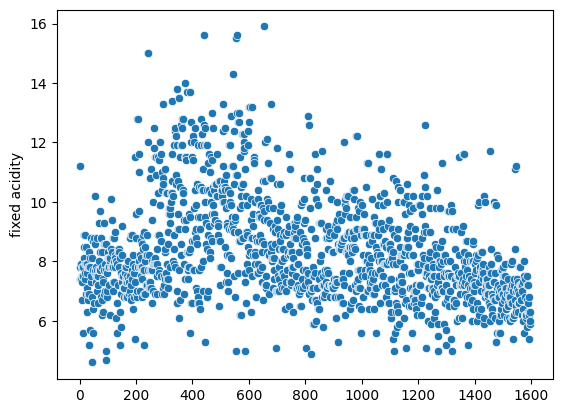

In [33]:
sns.scatterplot(df['fixed acidity'])

<Axes: ylabel='volatile acidity'>

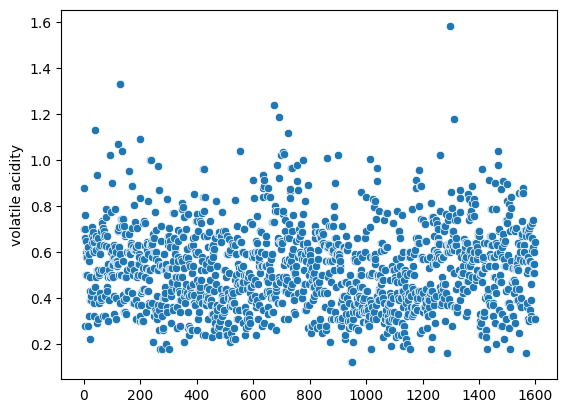

In [34]:
sns.scatterplot(df['volatile acidity'])

<Axes: ylabel='citric acid'>

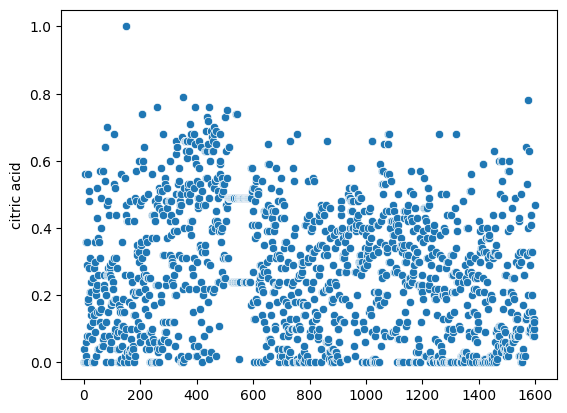

In [35]:
sns.scatterplot(df['citric acid'])

<Axes: ylabel='residual sugar'>

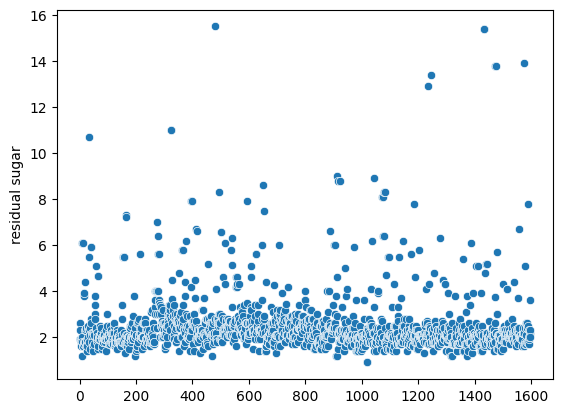

In [36]:
sns.scatterplot(df['residual sugar'])

<Axes: ylabel='chlorides'>

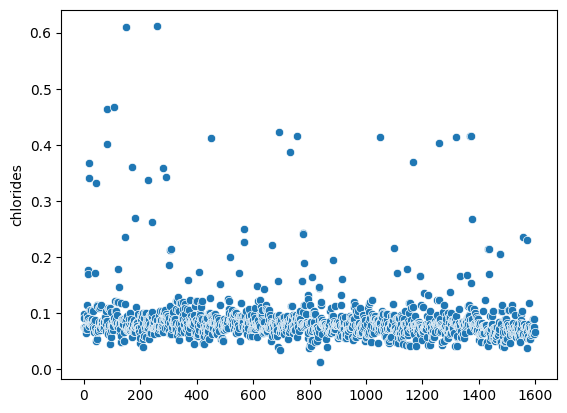

In [37]:
sns.scatterplot(df['chlorides'])

<Axes: ylabel='free sulfur dioxide'>

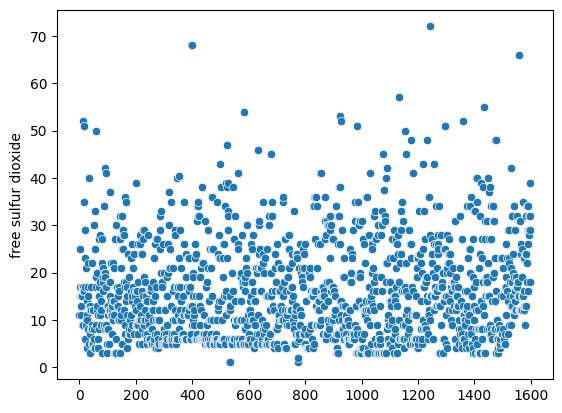

In [38]:
sns.scatterplot(df['free sulfur dioxide'])

<Axes: ylabel='total sulfur dioxide'>

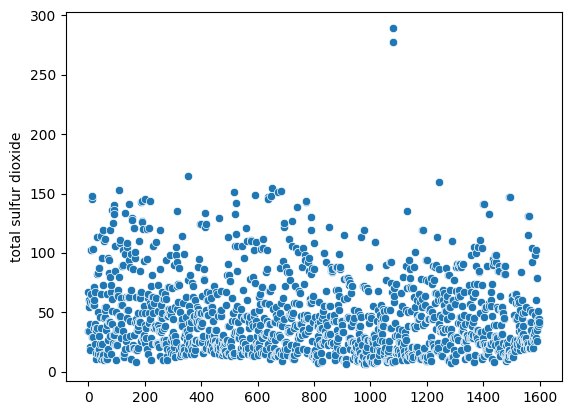

In [39]:
sns.scatterplot(df['total sulfur dioxide'])

<Axes: ylabel='density'>

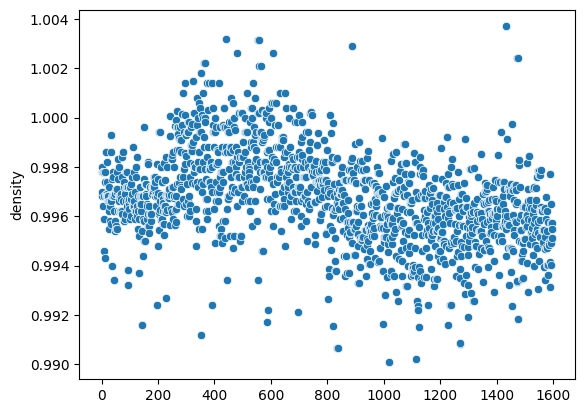

In [40]:
sns.scatterplot(df['density'])

<Axes: ylabel='pH'>

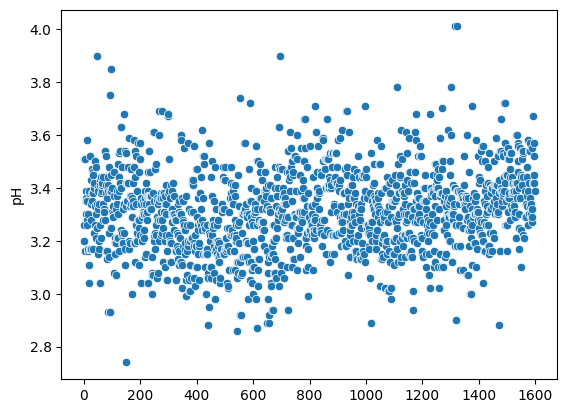

In [41]:
sns.scatterplot(df['pH'])

<Axes: ylabel='sulphates'>

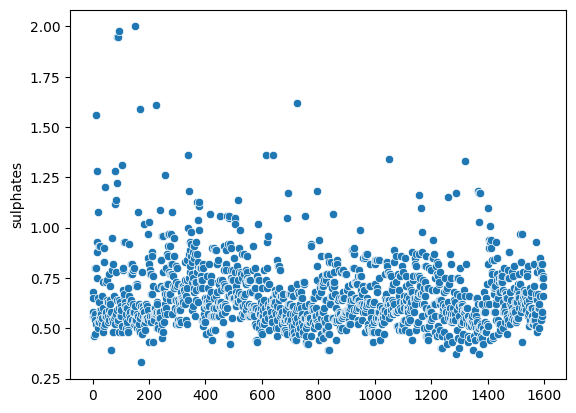

In [42]:
sns.scatterplot(df['sulphates'])

<Axes: ylabel='alcohol'>

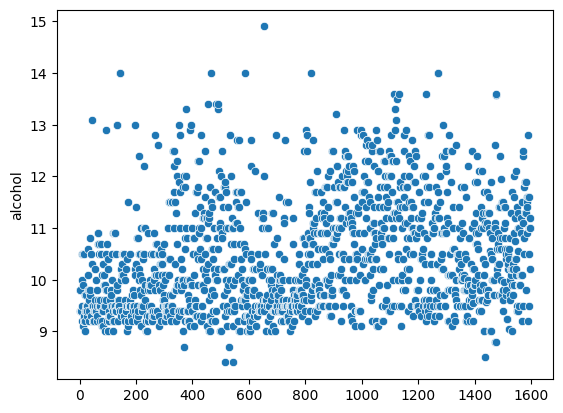

In [43]:
sns.scatterplot(df['alcohol'])

<Axes: ylabel='quality'>

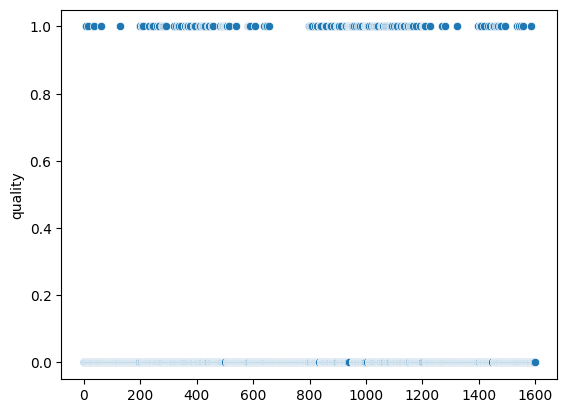

In [44]:
sns.scatterplot(df['quality'])

###Pandas Profiling

In [45]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 4.9 MB/s eta 0:00:00


In [46]:
from ydata_profiling import ProfileReport

In [47]:
profile = ProfileReport(df, explorative=True)

In [48]:
profile.to_file("EDA_of_Wine_Dataset.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 68.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Preprocessing

##Missing Values

In [49]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


##Duplicate Values

In [50]:
df.duplicated().sum()

np.int64(240)

In [51]:
df = df.drop_duplicates()

In [52]:
df.duplicated().sum()

np.int64(0)

###Data Type handling

In [53]:
df.sample(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
68,9.3,0.32,0.57,2.0,0.074,27.0,65.0,0.9969,3.28,0.79,10.7,0


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 138.0 KB


### Fixing outliers

In [55]:
profile.to_notebook_iframe()

Output hidden; open in https://colab.research.google.com to view.

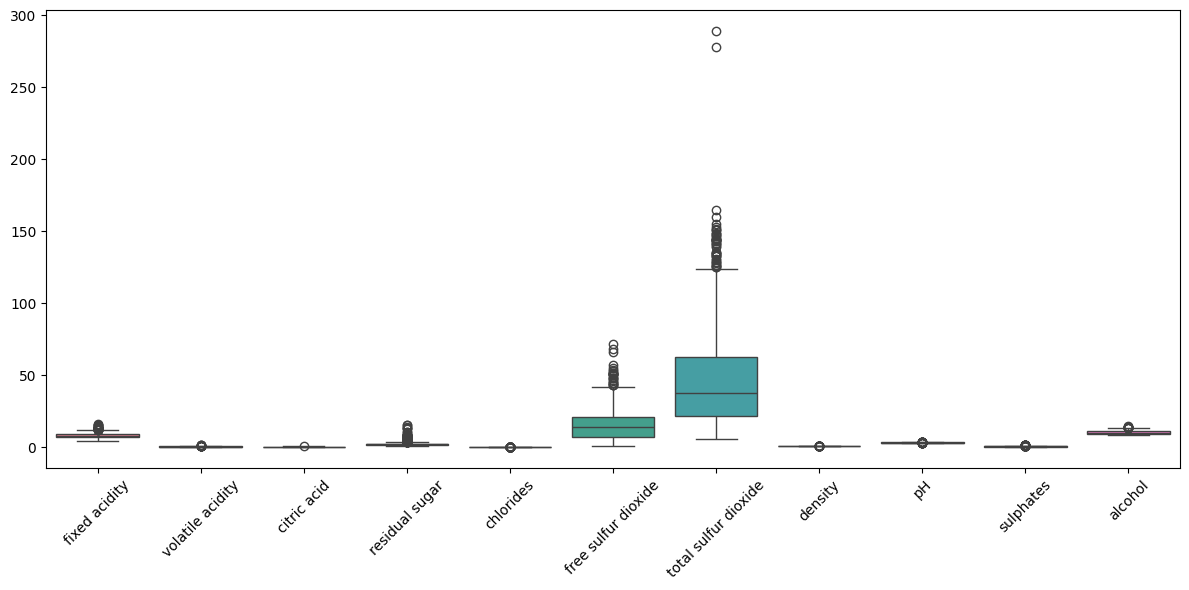

In [56]:
num_df = df.select_dtypes(include='number').drop(columns='quality')

plt.figure(figsize=(12, 6))
sns.boxplot(data=num_df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

> Fixing outliers using IQR method

In [57]:
df_clean = df.copy()

for col in df_clean.select_dtypes(include='number').columns:
    if col == 'quality':
        continue
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

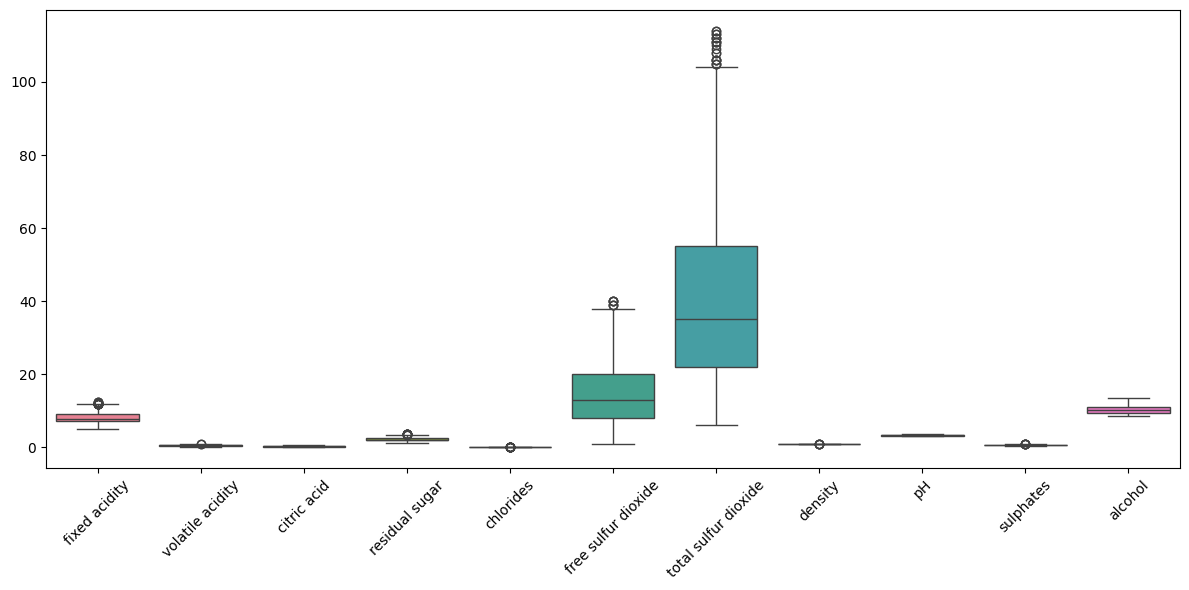

In [58]:
num_df = df_clean.select_dtypes(include='number').drop(columns='quality')

plt.figure(figsize=(12, 6))
sns.boxplot(data=num_df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

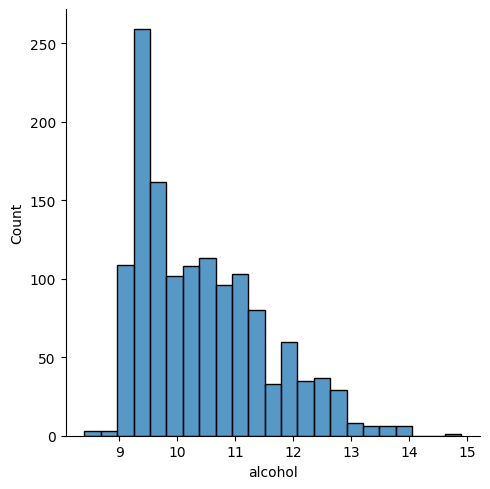

In [59]:
sns.displot(df['alcohol'])

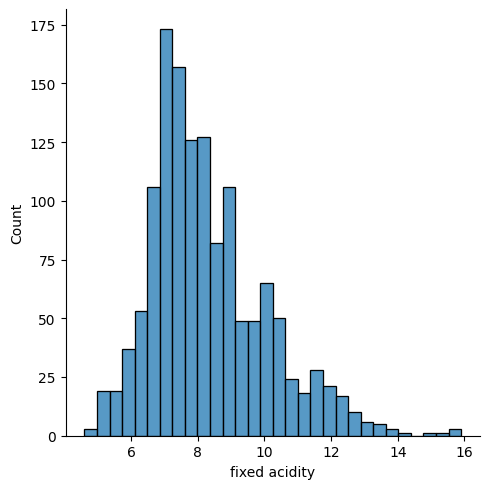

In [60]:
sns.displot(df['fixed acidity'])

/tmp/ipykernel_3167/1873944119.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_clean['volatile acidity'])


<Axes: xlabel='volatile acidity', ylabel='Density'>

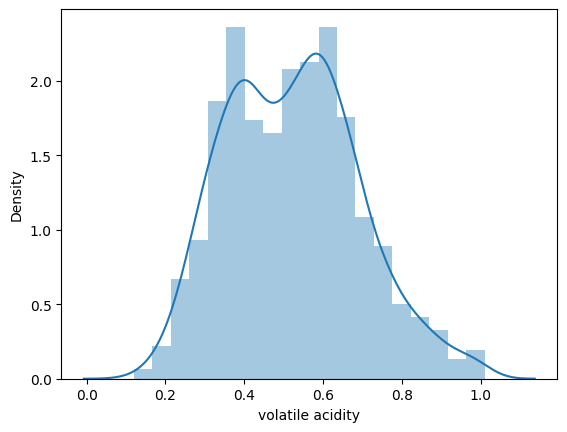

In [61]:
sns.distplot(df_clean['volatile acidity'])

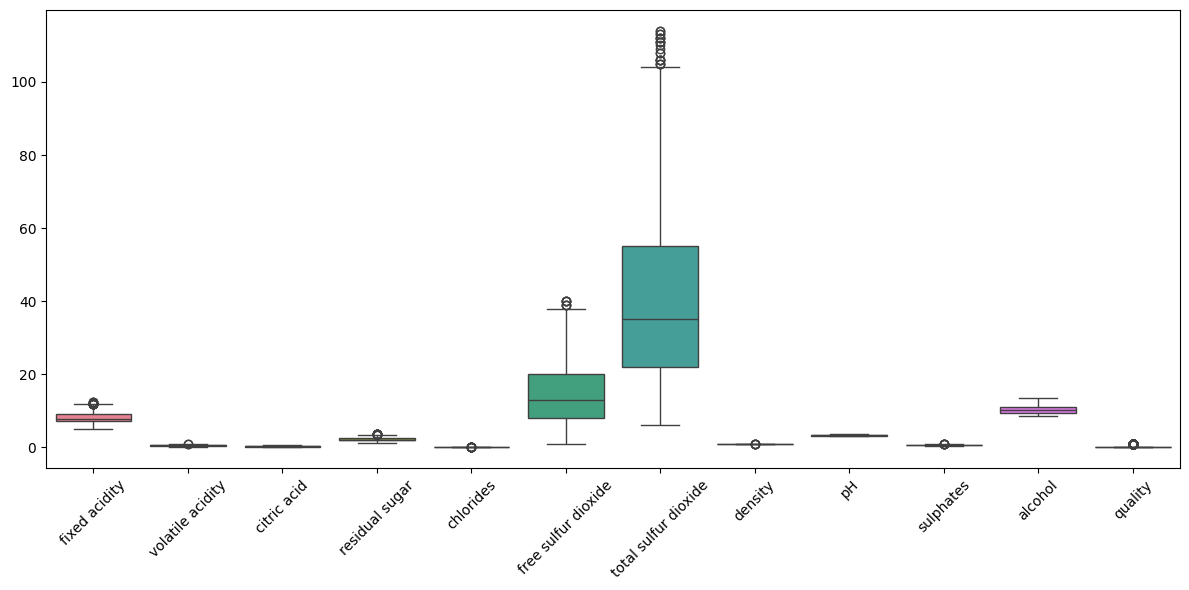

In [62]:
num_df = df_clean.select_dtypes(include='number')

plt.figure(figsize=(12, 6))
sns.boxplot(data=num_df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: ylabel='pH'>

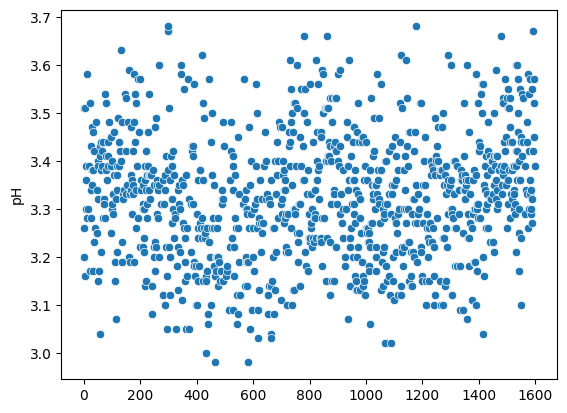

In [63]:
sns.scatterplot(df_clean['pH'])

In [95]:
from sklearn.preprocessing import MinMaxScaler

In [96]:
scaler = MinMaxScaler()

In [97]:
X = df_clean.drop(columns=['quality'])
y = df_clean['quality']

In [98]:
X = scaler.fit_transform(X)

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [101]:
X_train.shape

(788, 11)

## Training RandomForest

In [102]:
from sklearn.ensemble import RandomForestClassifier

In [103]:
model_rf = RandomForestClassifier()

In [104]:
model_rf.fit(X_train,y_train)

RandomForestClassifier()

In [107]:
y_pred = model_rf.predict(X_test)

In [108]:
from sklearn.metrics import accuracy_score

In [110]:
accuracy_score(y_pred, y_test)

0.8629441624365483

In [111]:
import joblib
joblib.dump(model_rf, "model.pkl")


['model.pkl']

In [115]:
model.predict([X_test[0]])


array([0])

In [118]:
y_test.head()

,quality
1024,1
768,0
1213,0
747,0
453,1


In [122]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

#Model Building Completed